In [10]:
!pip install anastruct
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from anastruct import SystemElements


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


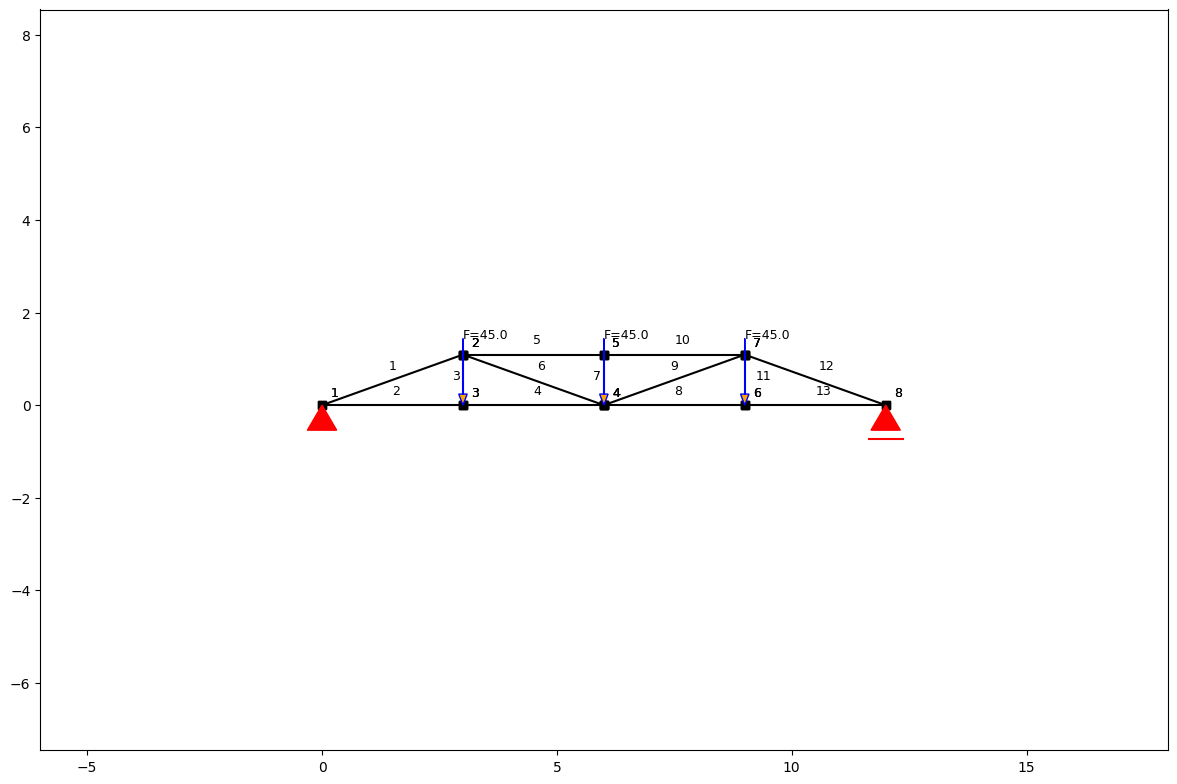

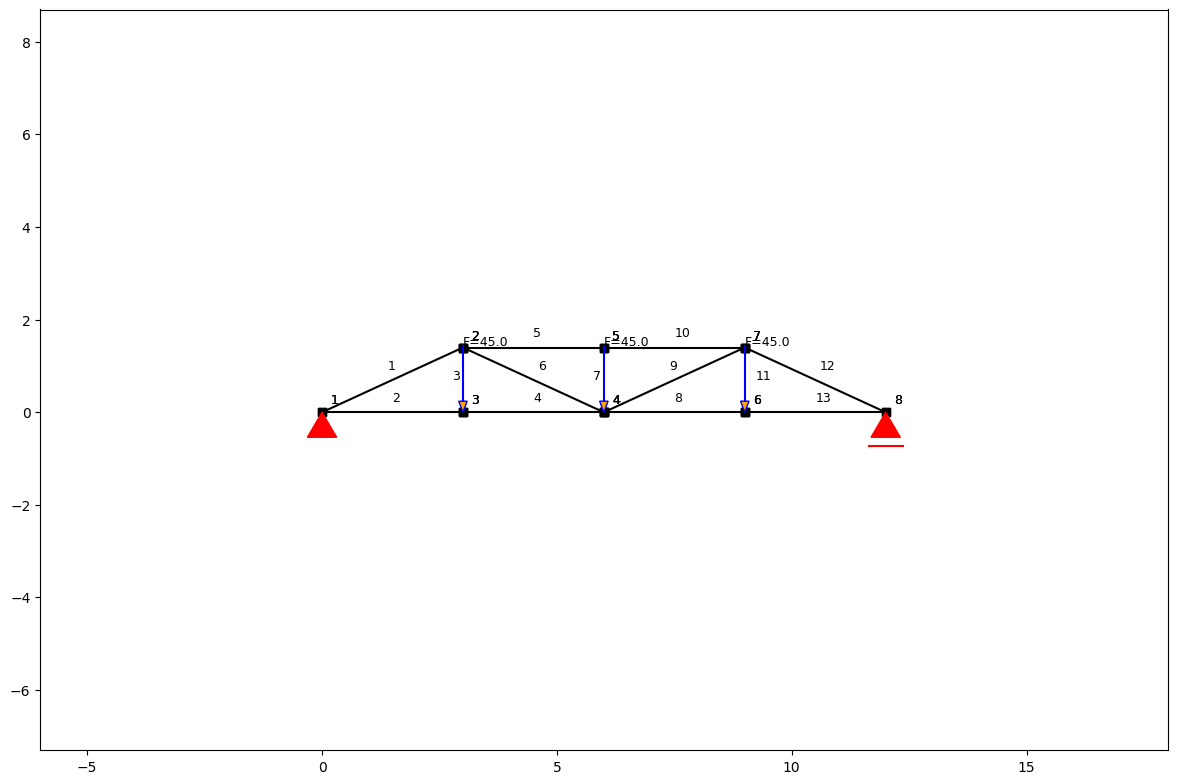

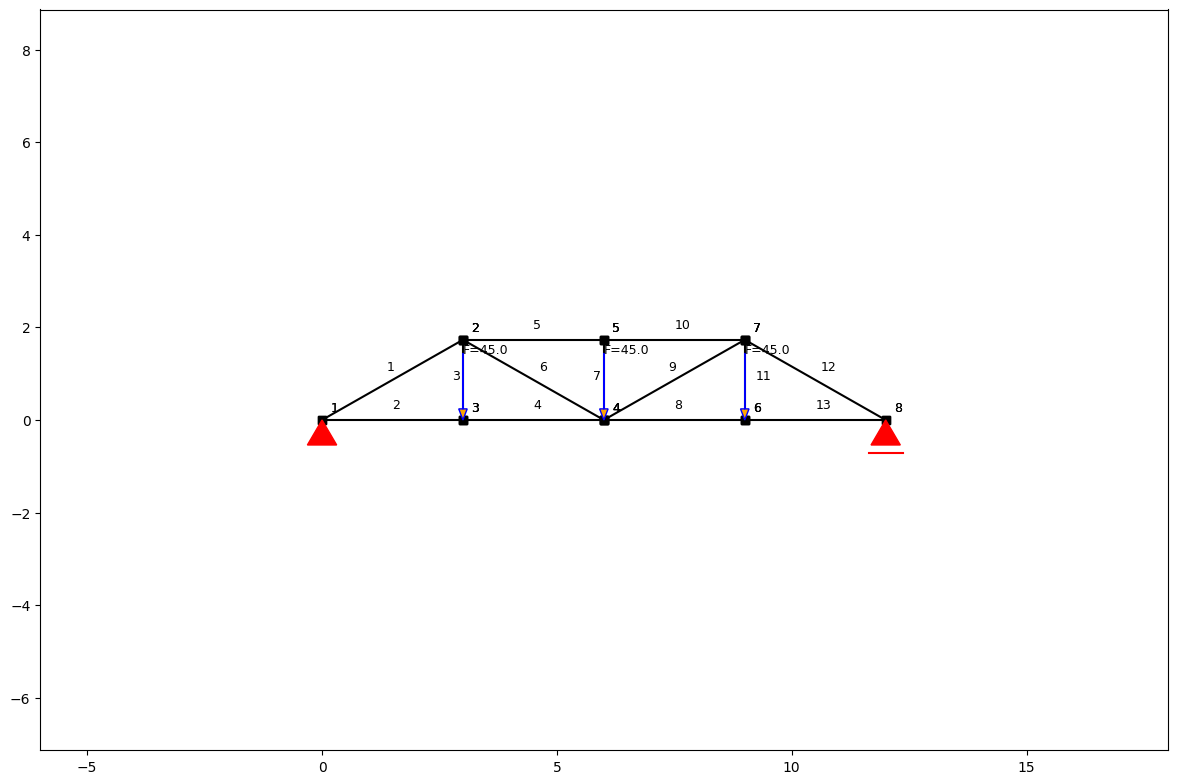

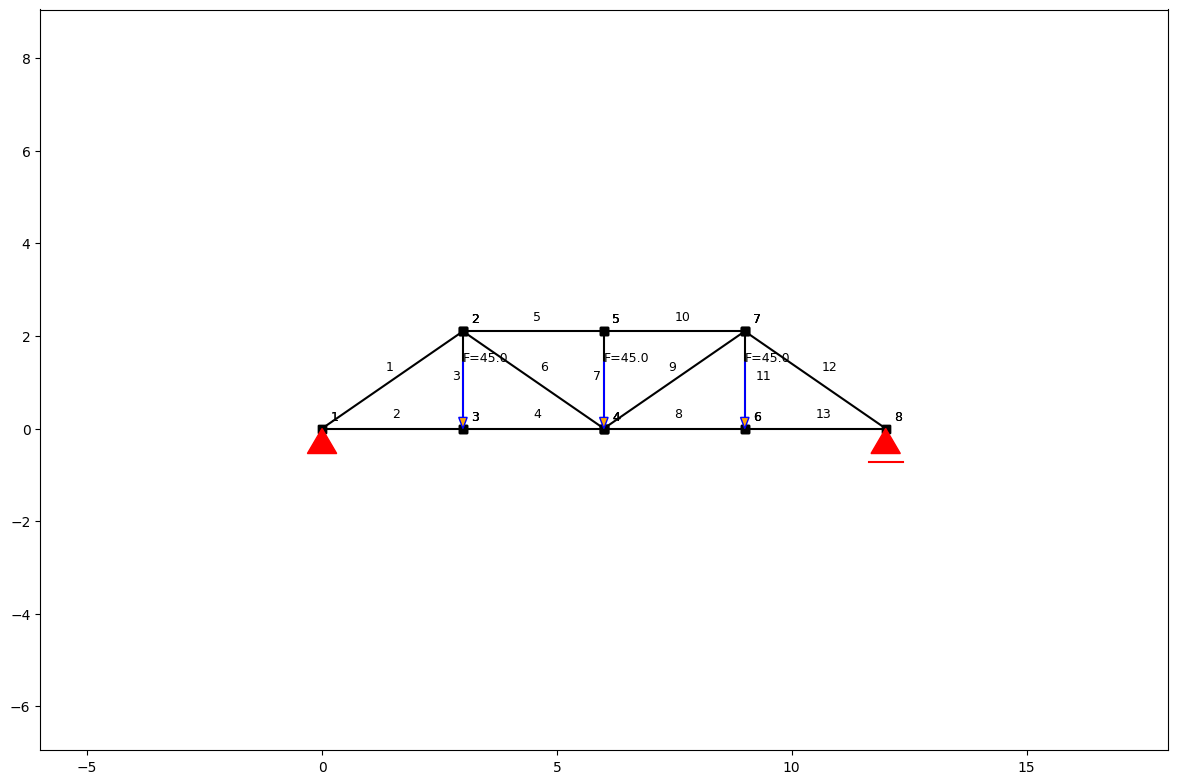

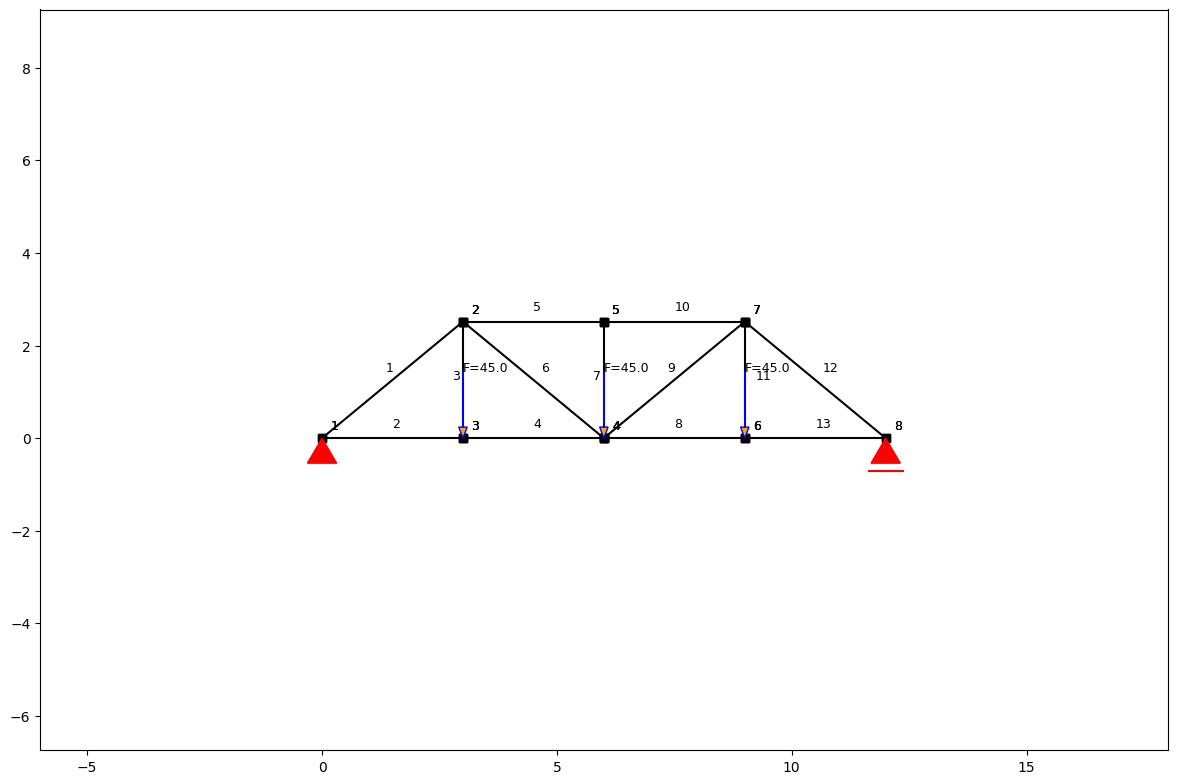

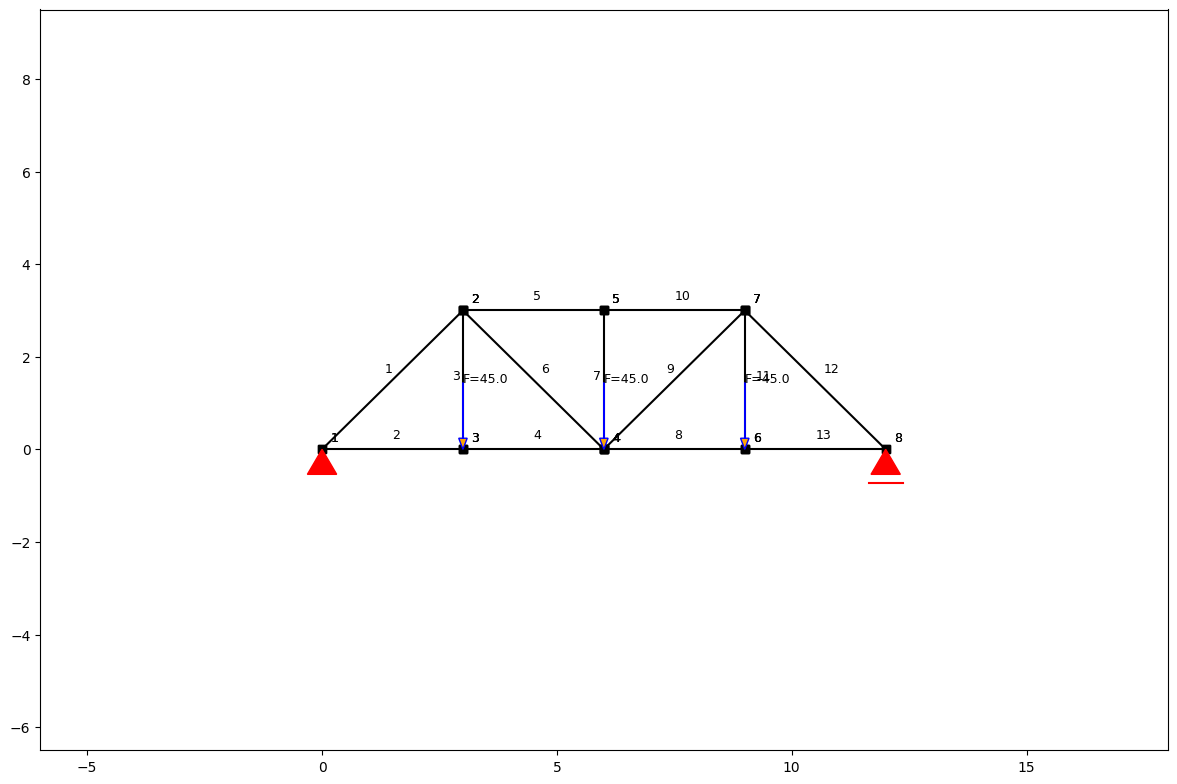

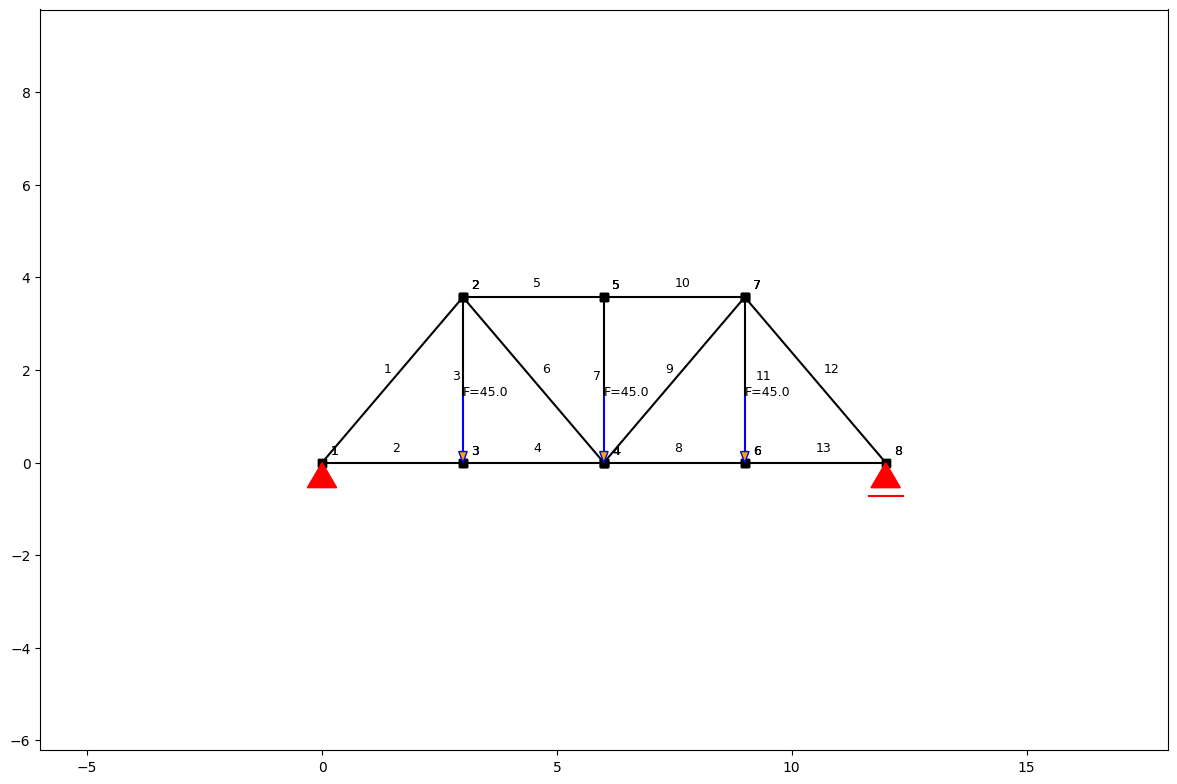

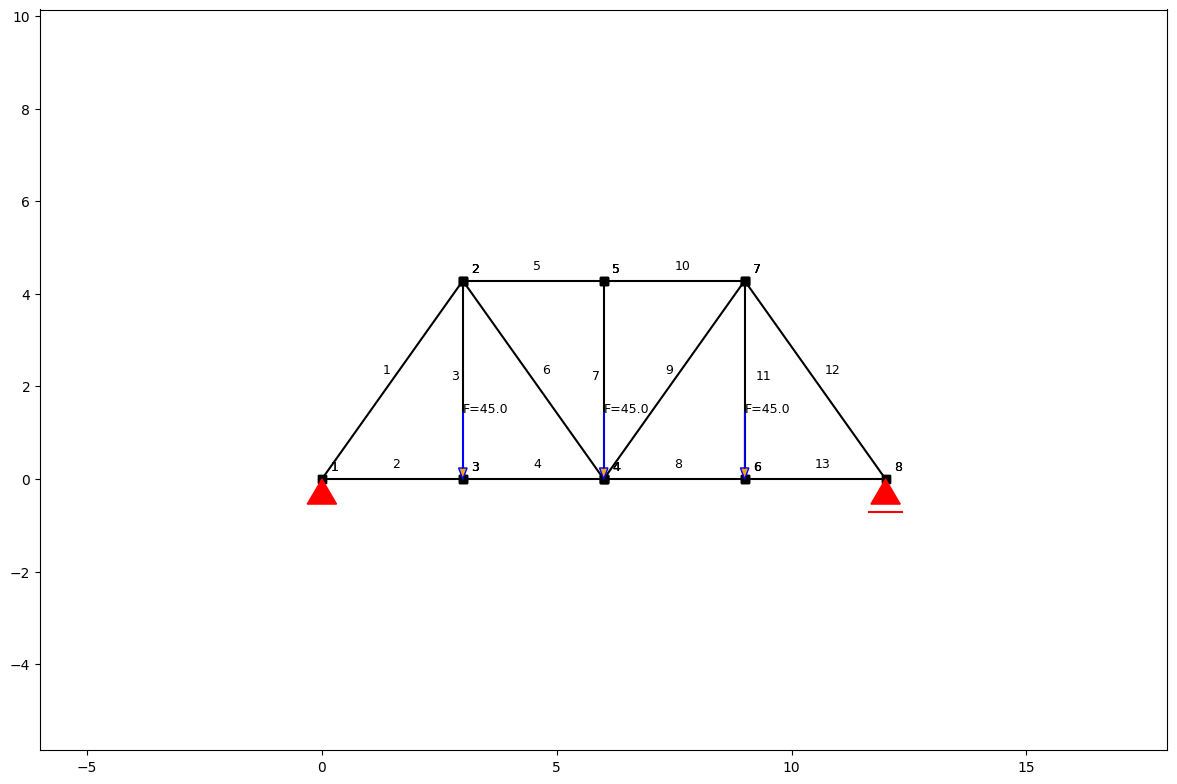

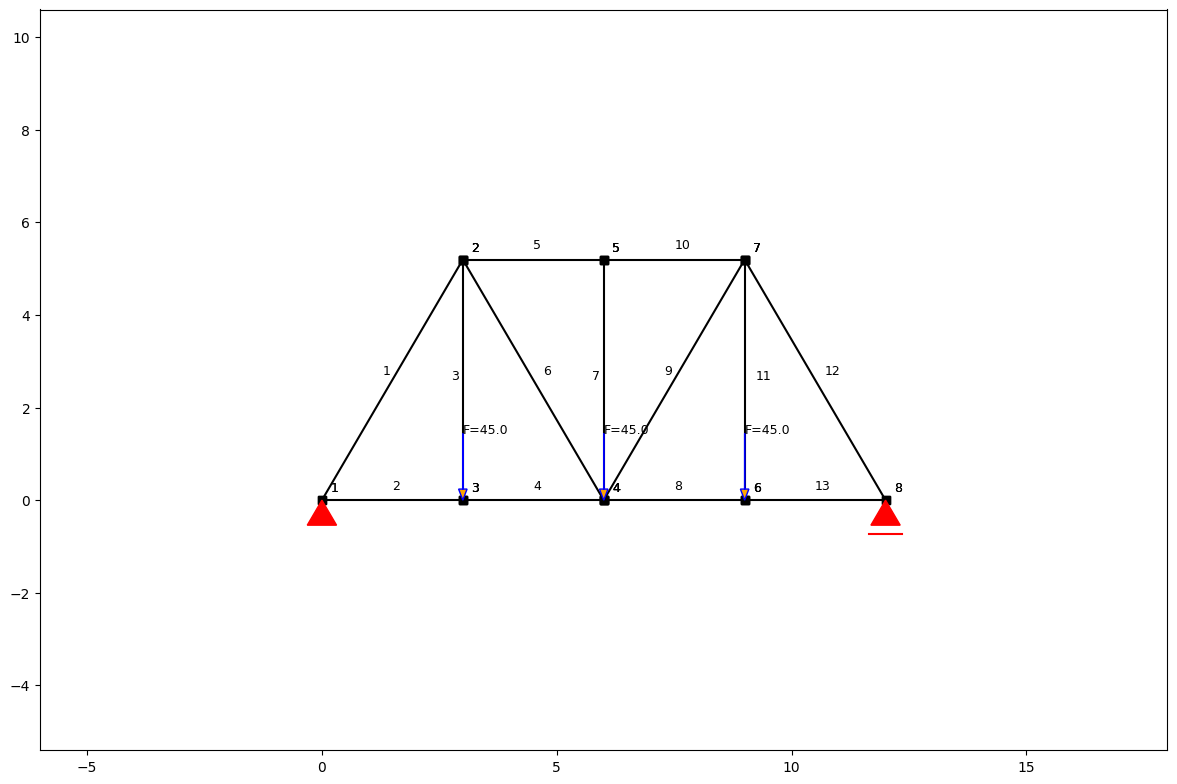

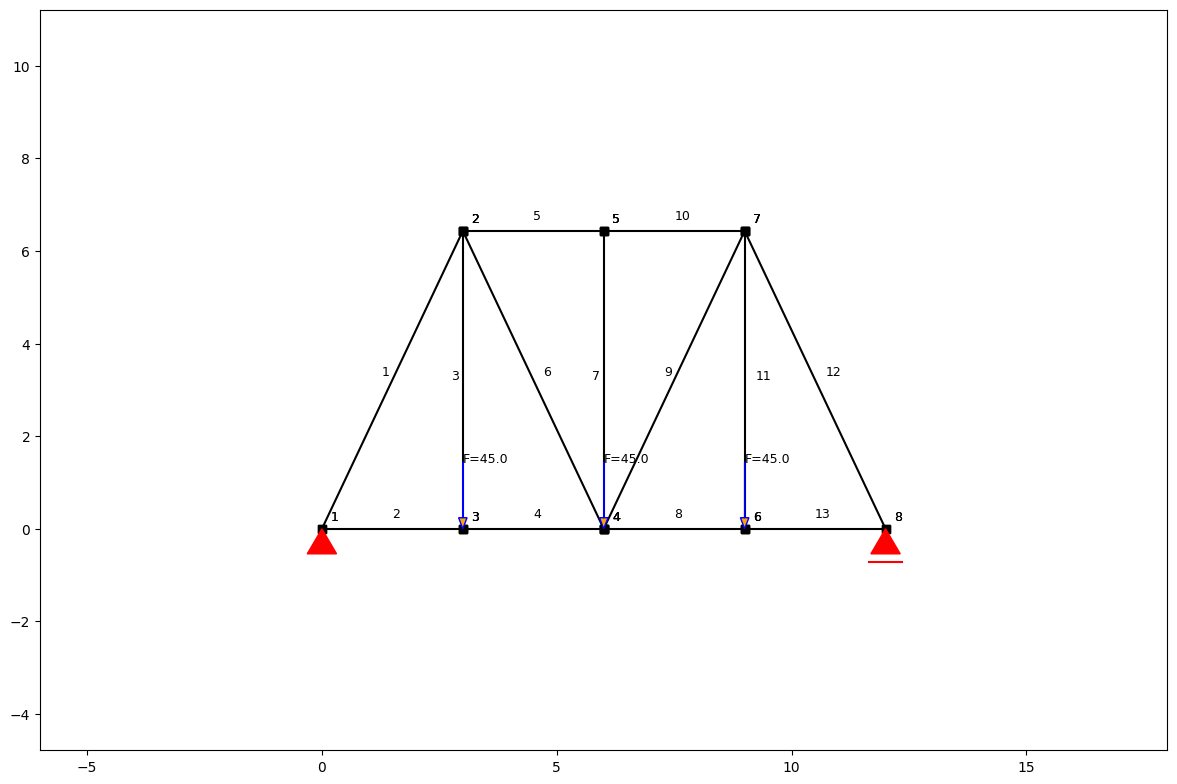

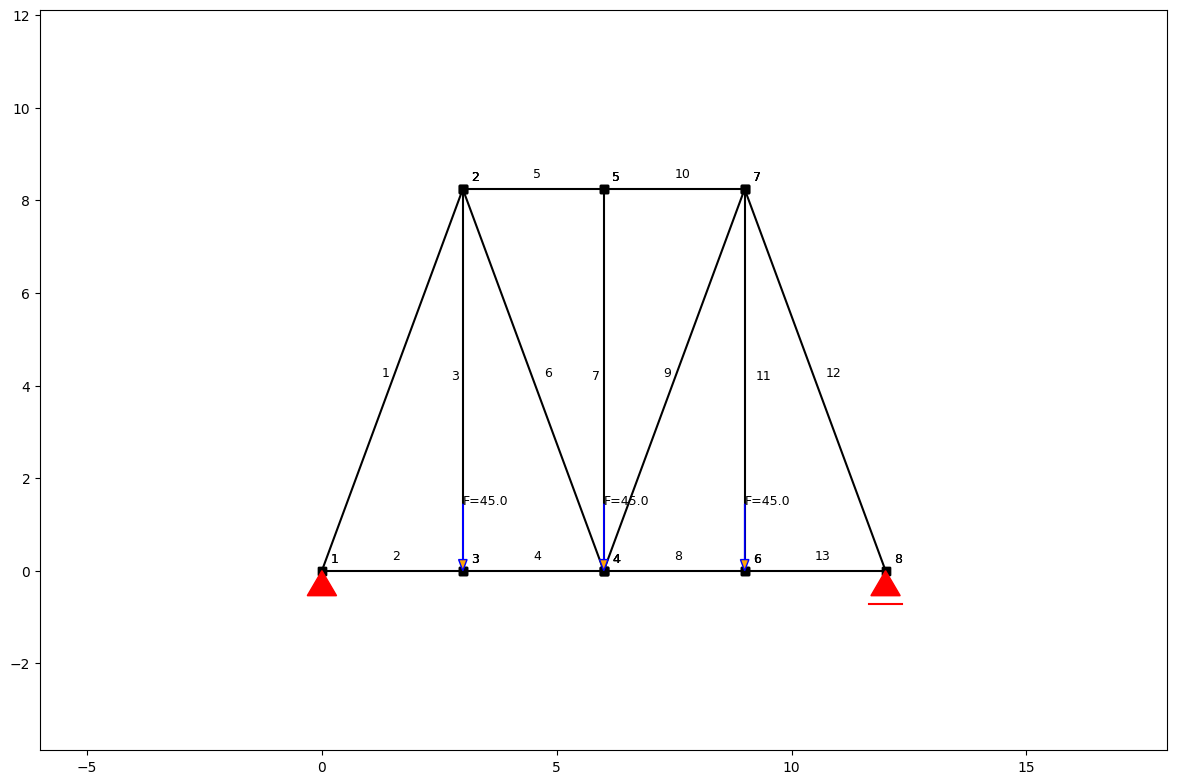

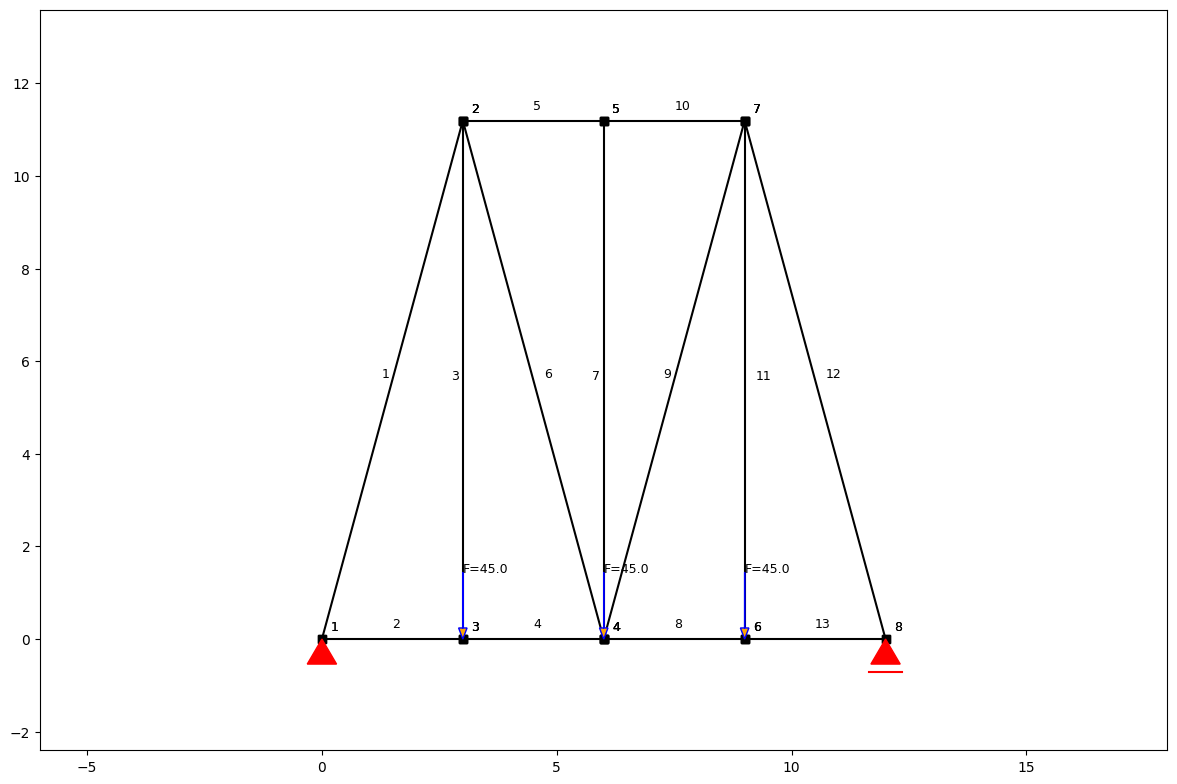

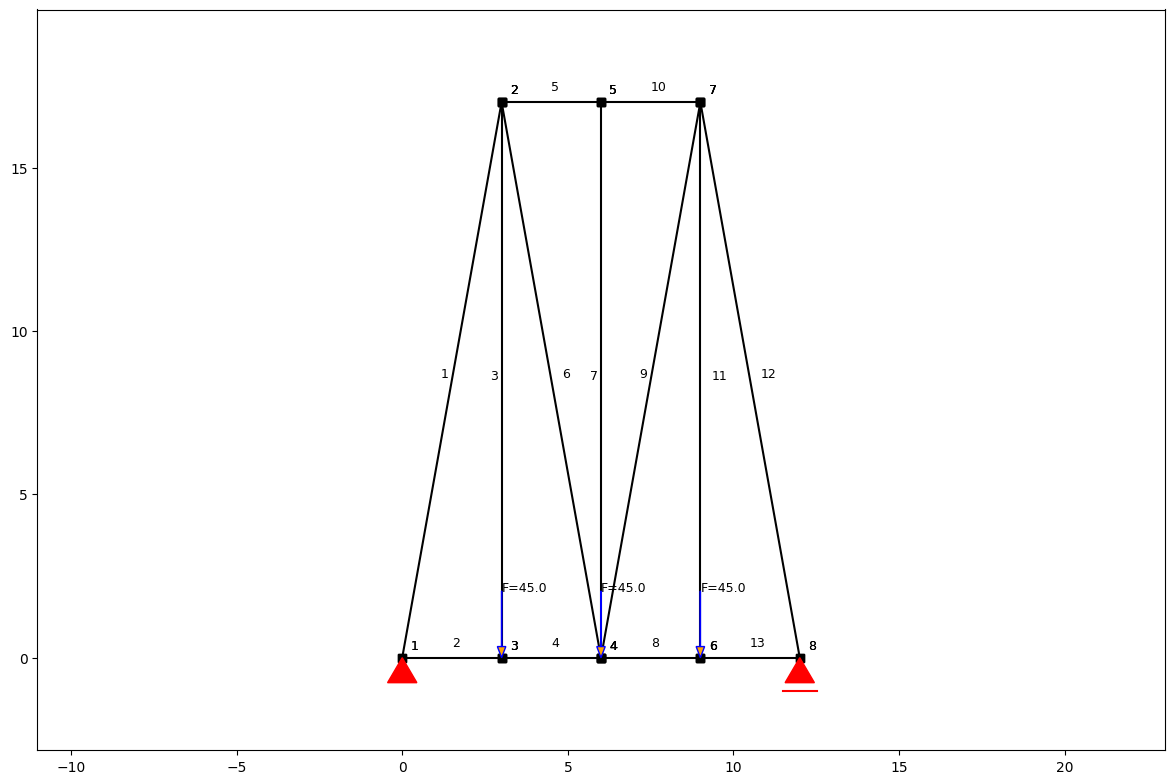

In [11]:
thetas = [20,25,30,35,40,45,50,55,60,65,70,75,80]
results = []
for theta in thetas:
  ss = SystemElements()
  x_a,y_a = 0 , 0
  x_b,y_b = 3 , 3*np.tan(theta*np.pi/180)
  x_c, y_c = 3, 0
  x_d, y_d = 6, 3*np.tan(theta*np.pi/180)
  x_e,y_e = 6,0
  x_f , y_f = 9,3*np.tan(theta*np.pi/180)
  x_g, y_g = 9,0
  x_h, y_h = 12,0
  nodes = {
    'A' : [x_a ,y_a],
    'B' : [x_b,y_b],
    'C' : [x_c, y_c],
    'D' : [x_d,y_d],
    'E' : [x_e,y_e],
    'F' : [x_f,y_f],
    'G' : [x_g,y_g],
    'H' : [x_h, y_h]
  }
  conec = [
      ['A','B'],['A', 'C'],['C','B'], ['C', 'E'],['B', 'D'], ['E', 'B'],['E','D'],['E' , 'G'],['E','F'],['D','F'],['F','G'],['F','H'],['H','G']
  ]
  load = {'C' :  (0, -45, 0), 'E' : (0,-45,0), 'G' : (0,-45,0)}

  support = {'A' : (1,1,0), 'H' : (0,1,0)}

  for n1, n2 in conec:
    coord1 = nodes[n1]
    coord2 = nodes[n2]
    ss.add_truss_element(location = [coord1,coord2])

  for name ,  (fx, fy, M) in load.items():
      node_coord = nodes[name]
      node_id = ss.find_node_id(node_coord)
      ss.point_load(node_id = node_id , Fx =fx ,Fy = fy)

  for s in support:
      node_id = ss.find_node_id(nodes[s])
      restr = support[s]
      if restr == (1,1,1):
          ss . add_support_fixed (node_id = node_id )
      elif restr == (1,1,0):
          ss.add_support_hinged(node_id = node_id)
      else:
        if restr [0] == 1:
          ss.add_support_roll(node_id = node_id,direction = 1)
        if restr [1] == 1:
          ss.add_support_roll(node_id = node_id,direction = 2)
  ss.solve()
  ss.show_structure()
  i = 0
  results.append(ss.get_element_results(element_id = i))
  i += 1

In [12]:
normal = np.zeros(shape = (13,13))

lengths = np.zeros(shape = (13,13))

for i in range(13):
  for j in range(13):
    normal[i][j] = results[i][j]["Nmax"]
    lengths[i][j] = results[i][j]["length"]

In [14]:
length_df = pd.DataFrame(data = lengths)
length_df.index = [f"theta = {theta}" for theta in thetas]

normal_df = pd.DataFrame(data = normal)
normal_df.index = [f"theta = {theta}" for theta in thetas]

diametros = np.sqrt(4*np.abs(normal * 10e3)/ (140e6 * np.pi))

diametros_df = pd.DataFrame(data = diametros)
diametros_df.index = [f"theta = {theta}" for theta in thetas]

volume = (np.pi*diametros**2/4)*lengths
volumes_df = pd.DataFrame(data = volume)
volumes_df.index = [f"{theta}" for theta in thetas]

p_esp = 78000*volumes_df
pesp_df = pd.DataFrame(data = p_esp)
pesp_df.index = [f"{theta}" for theta in thetas]

pesos = pesp_df.sum(axis = 1)
pesos

20    30573.482270
25    24686.038422
30    20843.994477
35    18198.334747
40    16335.901883
45    15042.856871
50    14213.932629
55    13818.213043
60    13895.996335
65    14588.072928
70    16231.580319
75    19663.717533
80    27450.408202
dtype: float64

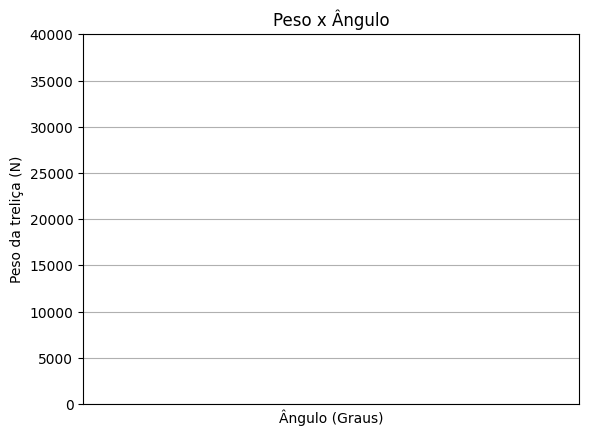

In [16]:
plt.plot(pesos)
plt.title("Peso x Ângulo")
plt.xlabel("Ângulo (Graus)")
plt.ylabel("Peso da treliça (N)")
plt.grid()
plt.axis([20,80,0,40000])
plt.show()
